Մուտքագրիր թվերը բացատներով: 6 5  5 3 5
6


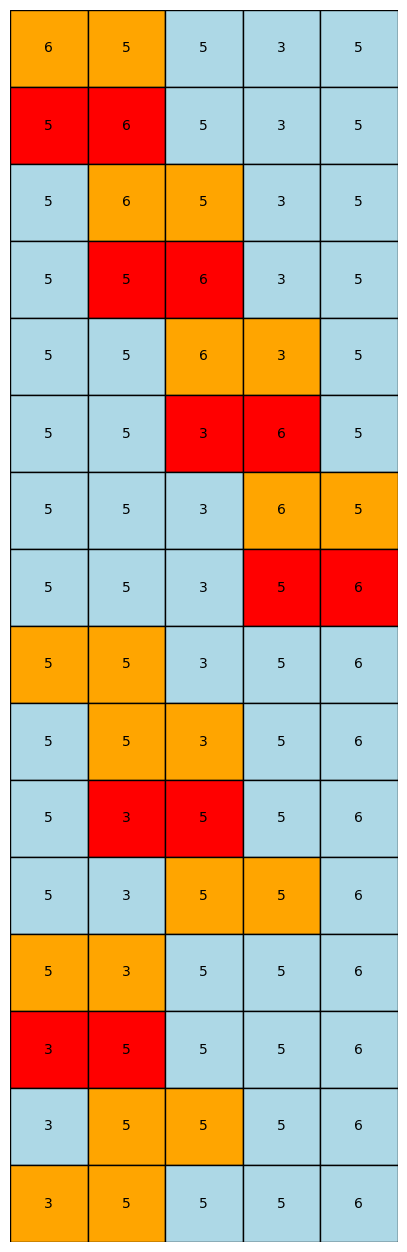

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def bubble_sort_steps(arr):
    arr = arr.copy()
    steps = []
    n = len(arr)
    q = 0
    for i in range(n):
        swapped = False
        for j in range(0, n - i - 1):
            steps.append((arr.copy(), j, j+1, False))

            if arr[j] > arr[j + 1]:
                q+=1
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True
                steps.append((arr.copy(), j, j+1, True))

        if not swapped:
            break
    print(q)
    return steps


def plot_steps(steps):
    rows = len(steps)
    cols = len(steps[0][0])

    fig, ax = plt.subplots(figsize=(cols, rows))

    for row, (arr, i, j, swapped) in enumerate(steps):
        for col, val in enumerate(arr):

            color = "lightblue"

            if col == i or col == j:
                color = "red" if swapped else "orange"

            rect = patches.Rectangle((col, rows - row - 1),
                                     1, 1,
                                     edgecolor='black',
                                     facecolor=color)

            ax.add_patch(rect)

            ax.text(col + 0.5,
                    rows - row - 1 + 0.5,
                    str(val),
                    ha='center', va='center')

    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.axis("off")

    plt.show()


arr = list(map(int, input("Մուտքագրիր թվերը բացատներով: ").split()))
steps = bubble_sort_steps(arr)
plot_steps(steps)

In [ ]:
def quick_sort(arr):
    if len(arr) <= 1:
        return arr

    pivot = arr[-1]
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]

    return quick_sort(left) + middle + quick_sort(right)


print(quick_sort([5, 3, 8, 4, 2, 4, 8, 7, 2, 3, 9, 1, 5, 3, 6, 4, 5]))


[1, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 6, 7, 8, 8, 9]


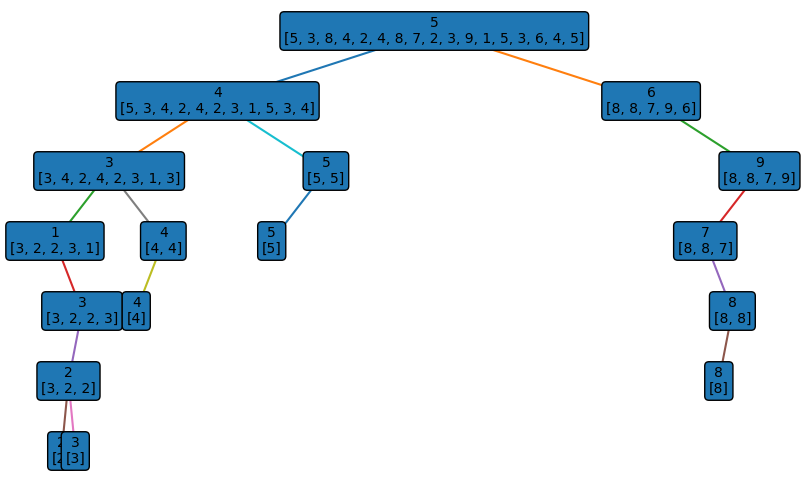

In [ ]:
import matplotlib.pyplot as plt


class Node:
    def __init__(self, arr):
        self.arr = arr
        self.pivot = None
        self.left = None
        self.right = None


def build_qs_tree(arr):
    if len(arr) == 0:
        return None

    node = Node(arr)

    if len(arr) == 1:
        node.pivot = arr[0]
        return node

    pivot = arr[-1]
    node.pivot = pivot

    left = [x for x in arr[:-1] if x <= pivot]
    right = [x for x in arr[:-1] if x > pivot]

    node.left = build_qs_tree(left)
    node.right = build_qs_tree(right)

    return node


# ── DRAW ───────────────────────────
def draw_tree(node, x=0, y=0, dx=4, pos=None, edges=None):
    if pos is None:
        pos = {}
    if edges is None:
        edges = []

    pos[node] = (x, y)

    if node.left:
        edges.append((node, node.left))
        draw_tree(node.left, x - dx, y - 1, dx/2, pos, edges)

    if node.right:
        edges.append((node, node.right))
        draw_tree(node.right, x + dx, y - 1, dx/2, pos, edges)

    return pos, edges


def plot_tree(root):
    pos, edges = draw_tree(root)

    plt.figure(figsize=(10, 6))

    # edges
    for p, c in edges:
        x1, y1 = pos[p]
        x2, y2 = pos[c]
        plt.plot([x1, x2], [y1, y2])

    for node, (x, y) in pos.items():
        label = f"{node.pivot}\n{node.arr}"
        plt.text(x, y, label,
                 ha="center", va="center",
                 bbox=dict(boxstyle="round"))

    plt.axis("off")
    plt.show()


root = build_qs_tree([5, 3, 8, 4, 2, 4, 8, 7, 2, 3, 9, 1, 5, 3, 6, 4, 5])
plot_tree(root)